# System Finder
This notebook is dedicated to finding resonances for multiple systems of the type 
$$
    V(r) = V_0 e^{-r^2/R^2} + V_b e^{-(r-r_b)^2/w^2}
$$

In [1]:
from src.dvr import DVR

import numpy as np
import matplotlib.pyplot as plt

In [2]:
n = 256
L = 50.0
phi_stable = 0.35


def gauss_barrier(V_0, R, V_b, r_b, w):
    def gauss(r):
        att_gauss = -V_0 * np.exp(-r**2/R**2)
        extra_barr = V_b * np.exp(-(r-r_b)**2/w**2)
        return att_gauss + extra_barr
    return gauss

In [3]:
V_0, R = 10.0, 1.0
r_b, w, V_b = 3.0, 1.5, 1.0

# testing
V_b = np.linspace(0.1, 2.0, 50)
spectrum = []
for v in V_b:
    gauss = gauss_barrier(V_0, R, v, r_b, w)
    pres_system = DVR(n, L, rotation_angle=phi_stable, potential=gauss, l=1)
    eigs, _ = pres_system.eig()
    spectrum.append(eigs)
spectrum = np.asarray(spectrum)

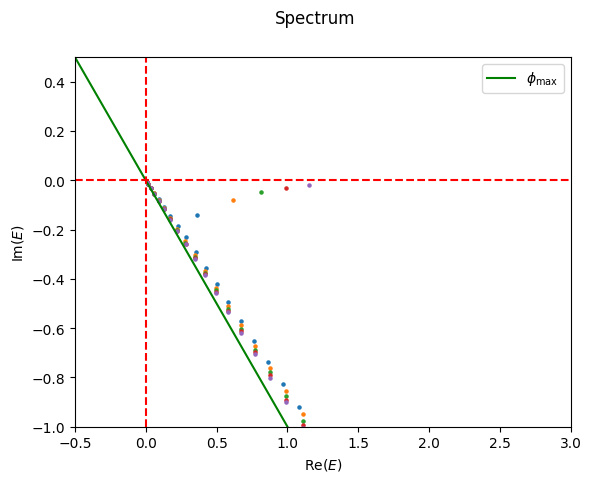

In [7]:
eigvals, _ = pres_system.eig()
fig, ax = plt.subplots()
ax.axline((0,0), (1, -np.tan(np.pi/4)), color='green', label=r'$\phi_\text{max}$')
for s in spectrum:
    ax.scatter(np.real(s), np.imag(s), s=5)
ax.axvline(0, linestyle='--', color='red')
ax.axhline(0, linestyle='--', color='red')
ax.set_xlabel(r"Re$(E)$")
ax.set_ylabel(r"Im$(E)$")
ax.legend()
ax.set_xlim([-0.5, 3.0])
ax.set_ylim([-1.0, 0.5])
fig.suptitle(r"Spectrum")
plt.show()

In [8]:
print(V_b[::10])

[0.1        0.4877551  0.8755102  1.26326531 1.65102041]
